In [132]:
# Importing Libraries #
import pandas as pd
from scipy import stats
from scipy import stats
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.metrics import recall_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix,classification_report)
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.tree import export_graphviz
import graphviz
from sklearn.tree import _tree
from sklearn.tree import export_text
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import MinMaxScaler
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [72]:
# Loading Dataset #
df = pd.read_csv('IMDb_Movies.csv')

In [73]:
# Understanding Dataset #
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5438 entries, 0 to 5437
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      5438 non-null   object 
 1   rating    5426 non-null   object 
 2   genre     5438 non-null   object 
 3   year      5438 non-null   int64  
 4   released  5438 non-null   object 
 5   score     5438 non-null   float64
 6   votes     5438 non-null   int64  
 7   director  5438 non-null   object 
 8   writer    5438 non-null   object 
 9   star      5438 non-null   object 
 10  country   5437 non-null   object 
 11  budget    5438 non-null   int64  
 12  gross     5438 non-null   int64  
 13  company   5436 non-null   object 
 14  runtime   5437 non-null   float64
dtypes: float64(2), int64(4), object(9)
memory usage: 637.4+ KB


In [74]:
df.describe()

,year,score,votes,budget,gross,runtime
count,5438.000000,5438.000000,5.438000e+03,5.438000e+03,5.438000e+03,5437.000000
mean,2001.644171,6.392460,1.148736e+05,3.592726e+07,1.029853e+08,108.151738
std,10.546973,0.963224,1.842021e+05,4.154441e+07,1.870759e+08,18.122132
min,1980.000000,1.900000,1.950000e+02,3.000000e+03,3.090000e+02,63.000000
25%,1993.000000,5.800000,1.900000e+04,1.000000e+07,1.066997e+07,95.000000
50%,2002.000000,6.500000,5.200000e+04,2.100000e+07,3.671199e+07,105.000000
75%,2010.750000,7.100000,1.290000e+05,4.500000e+07,1.118741e+08,118.000000
max,2020.000000,9.300000,2.400000e+06,3.560000e+08,2.847246e+09,271.000000


In [75]:
df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,Trojan War,PG-13,Comedy,1997,"October 1, 1997 (Brazil)",5.7,5800,George Huang,Andy Burg,Will Friedle,United States,15000000,309,Daybreak,85.0
1,Madadayo,NaN,Drama,1993,"April 17, 1993 (Japan)",7.3,5100,Akira Kurosawa,Ishirô Honda,Tatsuo Matsumura,Japan,11900000,596,DENTSU Music And Entertainment,134.0
2,Parasite,R,Horror,1982,"March 12, 1982 (United States)",3.9,2300,Charles Band,Alan J. Adler,Robert Glaudini,United States,800000,2270,Embassy Pictures,85.0
3,Ginger Snaps,Not Rated,Drama,2000,"May 11, 2001 (Canada)",6.8,43000,John Fawcett,Karen Walton,Emily Perkins,Canada,5000000,2554,Copperheart Entertainment,108.0
4,Philadelphia Experiment II,PG-13,Action,1993,"June 4, 1994 (South Korea)",4.5,1900,Stephen Cornwell,Wallace C. Bennett,Brad Johnson,United States,5000000,2970,Trimark Pictures,97.0


In [76]:
df.tail()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
5433,Avengers: Infinity War,PG-13,Action,2018,"April 27, 2018 (United States)",8.4,897000,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,321000000,2048359754,Marvel Studios,149.0
5434,Star Wars: Episode VII - The Force Awakens,PG-13,Action,2015,"December 18, 2015 (United States)",7.8,876000,J.J. Abrams,Lawrence Kasdan,Daisy Ridley,United States,245000000,2069521700,Lucasfilm,138.0
5435,Titanic,PG-13,Drama,1997,"December 19, 1997 (United States)",7.8,1100000,James Cameron,James Cameron,Leonardo DiCaprio,United States,200000000,2201647264,Twentieth Century Fox,194.0
5436,Avengers: Endgame,PG-13,Action,2019,"April 26, 2019 (United States)",8.4,903000,Anthony Russo,Christopher Markus,Robert Downey Jr.,United States,356000000,2797501328,Marvel Studios,181.0
5437,Avatar,PG-13,Action,2009,"December 18, 2009 (United States)",7.8,1100000,James Cameron,James Cameron,Sam Worthington,United States,237000000,2847246203,Twentieth Century Fox,162.0


In [77]:
df.dtypes

name         object
rating       object
genre        object
year          int64
released     object
score       float64
votes         int64
director     object
writer       object
star         object
country      object
budget        int64
gross         int64
company      object
runtime     float64
dtype: object

In [78]:
df.shape

(5438, 15)

In [79]:
# Missing Values#
df.isnull().sum()

name         0
rating      12
genre        0
year         0
released     0
score        0
votes        0
director     0
writer       0
star         0
country      1
budget       0
gross        0
company      2
runtime      1
dtype: int64

In [80]:
df = df.dropna(subset=['rating', 'company', 'country', 'runtime'])

In [81]:
df.isnull().sum()

name        0
rating      0
genre       0
year        0
released    0
score       0
votes       0
director    0
writer      0
star        0
country     0
budget      0
gross       0
company     0
runtime     0
dtype: int64

In [82]:
df.shape

(5423, 15)

In [83]:
# Duplicates #
df = df.drop_duplicates()

In [84]:
df.shape

(5423, 15)

In [85]:
# Checking released column #
df['released'].head(20)

0               October 1, 1997 (Brazil)
2         March 12, 1982 (United States)
3                  May 11, 2001 (Canada)
4             June 4, 1994 (South Korea)
5              January 15, 2015 (Sweden)
6         April 25, 1986 (United States)
7         August 9, 2012 (United States)
8          April 9, 1997 (United States)
9               January 19, 2001 (Italy)
10    September 18, 2000 (United States)
11     November 20, 1998 (United States)
12            September 4, 2014 (Israel)
13     November 15, 1985 (United States)
14       October 8, 1993 (United States)
15    September 12, 2014 (United States)
16          April 22, 2000 (South Korea)
17                 July 2, 2011 (Taiwan)
18            March 1985 (United States)
19         May 14, 1999 (United Kingdom)
20            March 31, 1994 (Australia)
Name: released, dtype: object

In [86]:
# Part A #
# Cleaning released column #
df['release_date_clean'] = df['released'].astype(str).str.split(r' \(').str[0]

def fix_missing_day(date_str):
    parts = date_str.split()
   
    if len(parts) == 2 and parts[0].isalpha() and parts[1].isdigit() and len(parts[1]) == 4:
        return f"{parts[0]} 1, {parts[1]}"
    
    if len(parts) == 1 and parts[0].isdigit() and len(parts[0]) == 4:
        return f"January 1, {parts[0]}"
    
    # Otherwise keep as is, e.g. "October 1, 1997"
    return date_str

df['release_date_clean'] = df['release_date_clean'].apply(fix_missing_day)

# Converting to datetime 
df['release_date_clean'] = pd.to_datetime(df['release_date_clean'], errors='coerce')

print(df['release_date_clean'].head(20))
print("Number of unparsed dates (NaT):", df['release_date_clean'].isna().sum())


# Creating Date Variables #
df['release_year'] = df['release_date_clean'].dt.year
df['release_month'] = df['release_date_clean'].dt.month_name()
df['release_day'] = df['release_date_clean'].dt.day

# Function to determine the season #
def get_season(month):
    if month in ['March', 'April', 'May']:
        return 'Spring'
    elif month in ['June', 'July', 'August']:
        return 'Summer'
    elif month in ['September', 'October', 'November']:
        return 'Fall'
    else:
        return 'Winter'

df['release_season'] = df['release_month'].apply(get_season)

# Bin the Release Day #
# Bins: 1–5, 6–10, 11–15, 16–20, 21–25, 26–31
bins = [0, 5, 10, 15, 20, 25, 31]
labels = ['1-5', '6-10', '11-15', '16-20', '21-25', '26-31']
df['release_day_bin'] = pd.cut(df['release_day'], bins=bins, labels=labels)

# Adjust for Inflation #
# Formula: Budget * (1 + 0.0309)^(2025 - year)
current_year = 2025
inflation_rate = 0.0309

df['budget_inflation_adjusted'] = df.apply(
    lambda row: row['budget'] * ((1 + inflation_rate) ** (current_year - row['year'])), axis=1
)

# Calculate Profit #
# Profit = Gross - Adjusted Budget
df['profit'] = df['gross'] - df['budget_inflation_adjusted']

# Create Extra Variables #
df['movie_name_length'] = df['name'].astype(str).str.len()
df['years_since_production'] = current_year - df['release_year']

# Check the Result #
print(df[['released', 'release_date_clean', 'profit']].head())

0    1997-10-01
2    1982-03-12
3    2001-05-11
4    1994-06-04
5    2015-01-15
6    1986-04-25
7    2012-08-09
8    1997-04-09
9    2001-01-19
10   2000-09-18
11   1998-11-20
12   2014-09-04
13   1985-11-15
14   1993-10-08
15   2014-09-12
16   2000-04-22
17   2011-07-02
18   1985-03-01
19   1999-05-14
20   1994-03-31
Name: release_date_clean, dtype: datetime64[ns]
Number of unparsed dates (NaT): 0
                         released release_date_clean        profit
0        October 1, 1997 (Brazil)         1997-10-01 -3.516823e+07
2  March 12, 1982 (United States)         1982-03-12 -2.958476e+06
3           May 11, 2001 (Canada)         2001-05-11 -1.069744e+07
4      June 4, 1994 (South Korea)         1994-06-04 -1.323737e+07
5       January 15, 2015 (Sweden)         2015-01-15 -4.876793e+06


In [87]:
key_vars = [
    'release_date_clean', 'release_year', 'release_month', 'release_day',
    'budget', 'gross', 'budget_inflation_adjusted', 'profit',
    'score', 'votes', 'runtime'
]

print(df[key_vars].isnull().sum())


release_date_clean           0
release_year                 0
release_month                0
release_day                  0
budget                       0
gross                        0
budget_inflation_adjusted    0
profit                       0
score                        0
votes                        0
runtime                      0
dtype: int64


In [ ]:
# Outliers #

In [106]:
# ---------- OUTLIER HANDLING (PART A) ----------

import numpy as np

# Function to cap outliers using the IQR rule
def cap_outliers_iqr(df, cols):
    df = df.copy()
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Winsorize: cap values outside the bounds
        df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
        df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

        print(f"{col}: capped below {lower_bound:.2f} and above {upper_bound:.2f}")
    return df

# Continuous variables where extreme outliers are likely and important
outlier_cols = [
    'budget_inflation_adjusted',
    'gross',
    'profit',
    'votes',
    'runtime',
    'score',
    'years_since_production'
]

# Before capping (optional sanity check)
print("Summary BEFORE capping:")
print(df[outlier_cols].describe())

# Apply IQR-based winsorization
df = cap_outliers_iqr(df, outlier_cols)

# After capping (optional sanity check)
print("\nSummary AFTER capping:")
print(df[outlier_cols].describe())


Summary BEFORE capping:
       budget_inflation_adjusted         gross        profit         votes  \
count               5.423000e+03  5.423000e+03  5.423000e+03  5.423000e+03   
mean                6.750756e+07  1.032104e+08  3.570279e+07  1.150285e+05   
std                 6.720907e+07  1.872734e+08  1.511219e+08  1.843838e+05   
min                 1.077001e+04  3.090000e+02 -2.912810e+08  1.950000e+02   
25%                 2.206125e+07  1.073081e+07 -2.560598e+07  1.900000e+04   
50%                 4.610505e+07  3.686941e+07 -2.154404e+06  5.200000e+04   
75%                 8.831346e+07  1.124030e+08  4.054904e+07  1.290000e+05   
max                 5.188227e+08  2.847246e+09  2.461579e+09  2.400000e+06   

           runtime        score  years_since_production  
count  5423.000000  5423.000000             5423.000000  
mean    108.148073     6.392274               23.192698  
std      18.116432     0.962754               10.556077  
min      63.000000     1.900000          

In [108]:
# Dummy Coding #
categorical_vars = ['rating', 'genre', 'company', 'release_season', 'release_day_bin']
df = pd.get_dummies(df, columns=categorical_vars, drop_first=True)

df.head()
df.shape

(5423, 1526)

In [110]:
#  MEASUREMENT TABLE #

measurement = []

for col in df.columns:
    if df[col].dtype in ['int64', 'float64']:
        measurement.append((col, 'Continuous'))
    else:
        measurement.append((col, 'Categorical'))

measurement_df = pd.DataFrame(measurement, columns=['variable_name', 'measurement'])
print(measurement_df.head(30))


                variable_name  measurement
0                        name  Categorical
1                        year   Continuous
2                    released  Categorical
3                       score   Continuous
4                       votes   Continuous
5                    director  Categorical
6                      writer  Categorical
7                        star  Categorical
8                     country  Categorical
9                      budget   Continuous
10                      gross   Continuous
11                    runtime   Continuous
12         release_date_clean  Categorical
13               release_year  Categorical
14              release_month  Categorical
15                release_day  Categorical
16  budget_inflation_adjusted   Continuous
17                     profit   Continuous
18          movie_name_length   Continuous
19     years_since_production   Continuous
20                   rating_G  Categorical
21               rating_NC-17  Categorical
22         

In [116]:
# Fix incorrect classifications manually
measurement_df.loc[measurement_df['variable_name'] == 'release_date_clean', 'measurement'] = 'Date/Continuous'
measurement_df.loc[measurement_df['variable_name'] == 'release_year', 'measurement'] = 'Continuous'
measurement_df.loc[measurement_df['variable_name'] == 'release_day', 'measurement'] = 'Continuous'

# Show corrected table
measurement_df.head(30)

,variable_name,measurement
0,name,Categorical
1,year,Continuous
2,released,Categorical
3,score,Continuous
4,votes,Continuous
5,director,Categorical
6,writer,Categorical
7,star,Categorical
8,country,Categorical
9,budget,Continuous


In [112]:
# ---------- SUMMARY STATISTICS (PART A) ----------

import pandas as pd

pd.set_option('display.float_format', '{:,.2f}'.format)

continuous_vars = [
    'budget',
    'budget_inflation_adjusted',
    'gross',
    'profit',
    'score',
    'votes',
    'runtime',
    'movie_name_length',
    'years_since_production'
]

summary_stats = df[continuous_vars].describe().T  # transpose to make it prettier
summary_stats['median'] = df[continuous_vars].median()
summary_stats = summary_stats[['mean', 'median', 'std', 'min', '25%', '50%', '75%', 'max']]

print(summary_stats)


                                   mean        median           std  \
budget                    35,997,734.86 21,500,000.00 41,570,081.03   
budget_inflation_adjusted 63,031,790.34 46,105,045.38 53,916,641.71   
gross                     75,577,345.49 36,869,414.00 86,248,936.50   
profit                    12,549,940.21 -2,154,404.01 63,614,972.01   
score                              6.40          6.50          0.93   
votes                         89,836.02     52,000.00     92,681.70   
runtime                          107.73        105.00         16.56   
movie_name_length                 14.88         13.00          7.99   
years_since_production            23.19         23.00         10.56   

                                      min            25%           50%  \
budget                           3,000.00  10,000,000.00 21,500,000.00   
budget_inflation_adjusted       10,770.01  22,061,245.64 46,105,045.38   
gross                              309.00  10,730,814.50 36,869,414

In [114]:
# ---------- CORRELATION TABLE (PART A) ----------

corr_matrix = df[continuous_vars].corr().round(2)
print(corr_matrix)


                           budget  budget_inflation_adjusted  gross  profit  \
budget                       1.00                       0.89   0.71    0.30   
budget_inflation_adjusted    0.89                       1.00   0.67    0.14   
gross                        0.71                       0.67   1.00    0.80   
profit                       0.30                       0.14   0.80    1.00   
score                        0.07                       0.03   0.22    0.28   
votes                        0.51                       0.45   0.73    0.63   
runtime                      0.33                       0.34   0.27    0.11   
movie_name_length            0.13                       0.10   0.12    0.10   
years_since_production      -0.32                      -0.10  -0.32   -0.36   

                           score  votes  runtime  movie_name_length  \
budget                      0.07   0.51     0.33               0.13   
budget_inflation_adjusted   0.03   0.45     0.34               0.10

In [118]:
# ---------- PART B: DESCRIPTIVE ANALYSIS ----------

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 0.1 Reload the original data for descriptive analysis
df_desc = pd.read_csv('IMDb_Movies.csv')

# 0.2 Drop missing values in key categorical/continuous variables (same rule as Part A)
df_desc = df_desc.dropna(subset=['rating', 'company', 'country', 'runtime'])

# 0.3 Clean the 'released' column and build date-based features (same as before)

df_desc['release_date_clean'] = df_desc['released'].astype(str).str.split(r' \(').str[0]

def fix_missing_day(date_str):
    parts = date_str.split()
    # Case 1: "March 1985" -> "March 1, 1985"
    if len(parts) == 2 and parts[0].isalpha() and parts[1].isdigit() and len(parts[1]) == 4:
        return f"{parts[0]} 1, {parts[1]}"
    # Case 2: "1985" -> "January 1, 1985"
    if len(parts) == 1 and parts[0].isdigit() and len(parts[0]) == 4:
        return f"January 1, {parts[0]}"
    return date_str

df_desc['release_date_clean'] = df_desc['release_date_clean'].apply(fix_missing_day)
df_desc['release_date_clean'] = pd.to_datetime(df_desc['release_date_clean'], errors='coerce')

# Drop any rows where the date totally failed (should be very few or none)
df_desc = df_desc.dropna(subset=['release_date_clean'])

# 0.4 Create date variables
df_desc['release_year'] = df_desc['release_date_clean'].dt.year
df_desc['release_month'] = df_desc['release_date_clean'].dt.month_name()
df_desc['release_day'] = df_desc['release_date_clean'].dt.day

def get_season(month):
    if month in ['March', 'April', 'May']:
        return 'Spring'
    elif month in ['June', 'July', 'August']:
        return 'Summer'
    elif month in ['September', 'October', 'November']:
        return 'Fall'
    else:
        return 'Winter'

df_desc['release_season'] = df_desc['release_month'].apply(get_season)

# 0.5 Release day bins
bins = [0, 5, 10, 15, 20, 25, 31]
labels = ['1-5', '6-10', '11-15', '16-20', '21-25', '26-31']
df_desc['release_day_bin'] = pd.cut(df_desc['release_day'], bins=bins, labels=labels, include_lowest=True)

# 0.6 Inflation-adjusted budget
current_year = 2025
inflation_rate = 0.0309
df_desc['budget_inflation_adjusted'] = df_desc['budget'] * ((1 + inflation_rate) ** (current_year - df_desc['year']))

# 0.7 Profit
df_desc['profit'] = df_desc['gross'] - df_desc['budget_inflation_adjusted']

# 0.8 Optional: apply the same IQR capping to make Part B numbers consistent
def cap_outliers_iqr(df, cols):
    df = df.copy()
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
        df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
    return df

outlier_cols = ['budget_inflation_adjusted', 'gross', 'profit', 'votes', 'runtime', 'score']
df_desc = cap_outliers_iqr(df_desc, outlier_cols)

# Nice plotting defaults
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)


In [120]:
# Q1: Top 10 production companies by average profit
q1_company_profit = (
    df_desc.groupby('company')['profit']
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
print("Q1 - Top 10 Companies by Average Profit:")
print(q1_company_profit)

# Q2: Top 10 production countries by average profit
q2_country_profit = (
    df_desc.groupby('country')['profit']
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
print("\nQ2 - Top 10 Countries by Average Profit:")
print(q2_country_profit)


Q1 - Top 10 Companies by Average Profit:
                               company         profit
0  "Weathering With You" Film Partners 139,781,558.52
1                        Waverly Films 139,781,558.52
2                      888 Productions 139,781,558.52
3                Warner Bros. Pictures 139,781,558.52
4        Constantin Film International 139,781,558.52
5           Claudie Ossard Productions 139,781,558.52
6                              Syncopy 139,781,558.52
7                        Tokuma Shoten 139,781,558.52
8      Estudios Churubusco Azteca S.A. 139,781,558.52
9              The Mark Gordon Company 139,781,558.52

Q2 - Top 10 Countries by Average Profit:
                country         profit
0                 Malta 139,781,558.52
1               Finland 104,776,205.57
2          South Africa  67,088,799.20
3                Taiwan  61,739,242.93
4               Lebanon  59,467,338.43
5                 China  56,909,366.68
6           New Zealand  45,643,607.32
7  United A

In [ ]:
# Helper function to make bar charts
def bar_chart_mean(x_col, y_col, title, xlabel, ylabel):
    temp = (
        df_desc.groupby(x_col)[y_col]
        .mean()
        .sort_values(ascending=False)
        .reset_index()
    )

    plt.figure()
    sns.barplot(data=temp, x=x_col, y=y_col)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Q3: Which genres are more expensive to make?
bar_chart_mean(

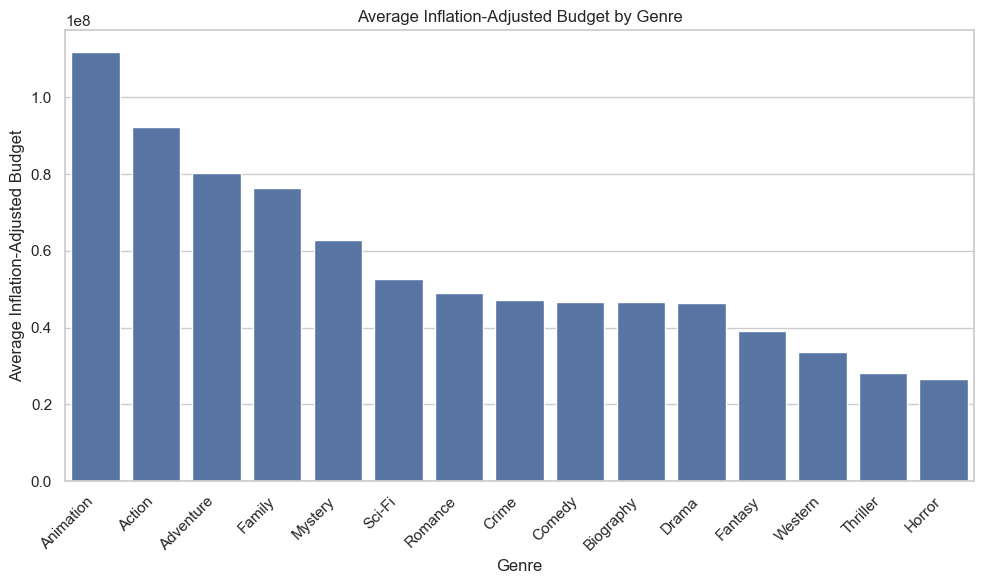

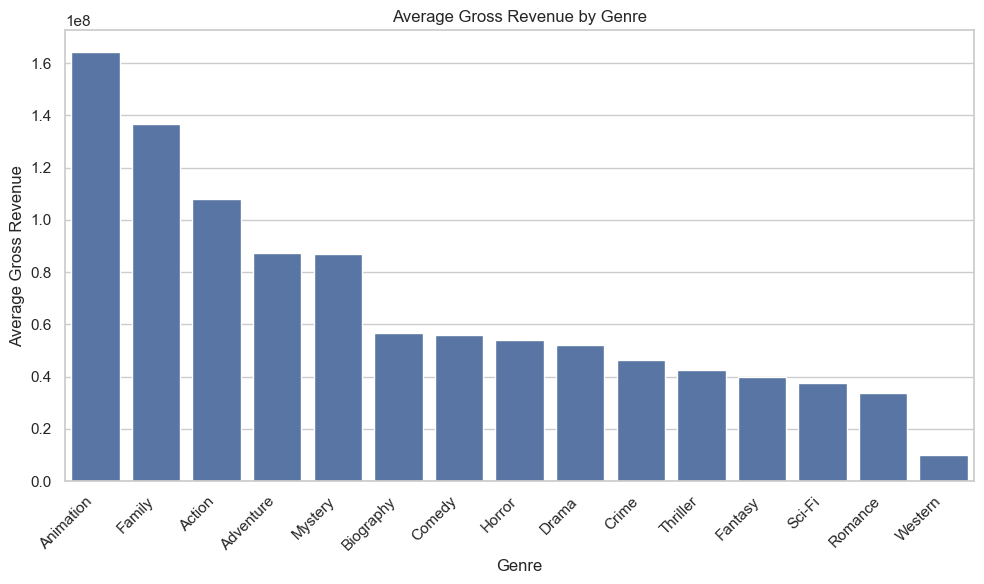

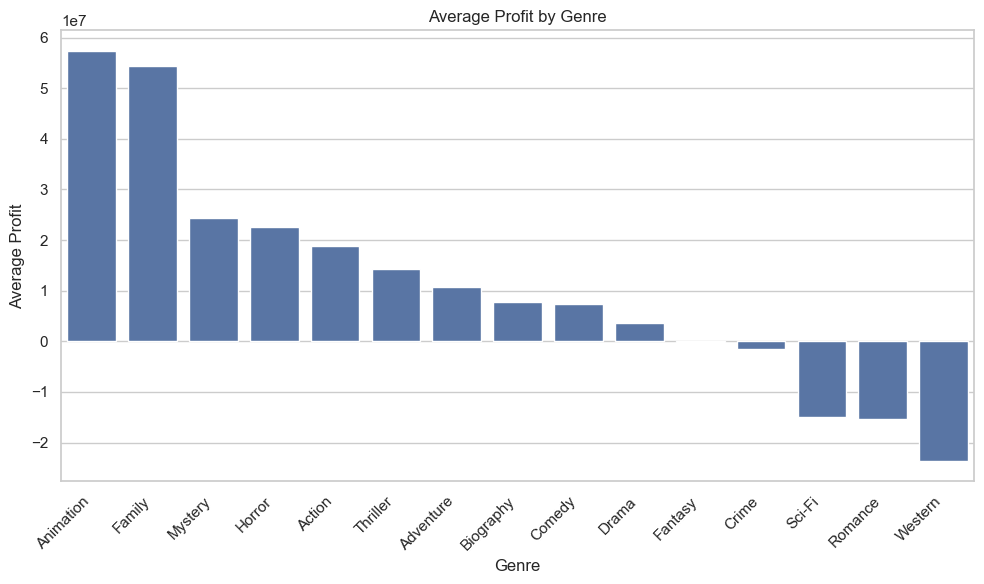

In [ ]:
    x_col='genre',
    y_col='budget_inflation_adjusted',
    title='Average Inflation-Adjusted Budget by Genre',
    xlabel='Genre',
    ylabel='Average Inflation-Adjusted Budget'
)

# Q4: Which genres tend to produce higher gross revenues?
bar_chart_mean(
    x_col='genre',
    y_col='gross',
    title='Average Gross Revenue by Genre',
    xlabel='Genre',
    ylabel='Average Gross Revenue'
)

# Q5: Which genres tend to generate more profit?
bar_chart_mean(
    x_col='genre',
    y_col='profit',
    title='Average Profit by Genre',
    xlabel='Genre',
    ylabel='Average Profit'
)

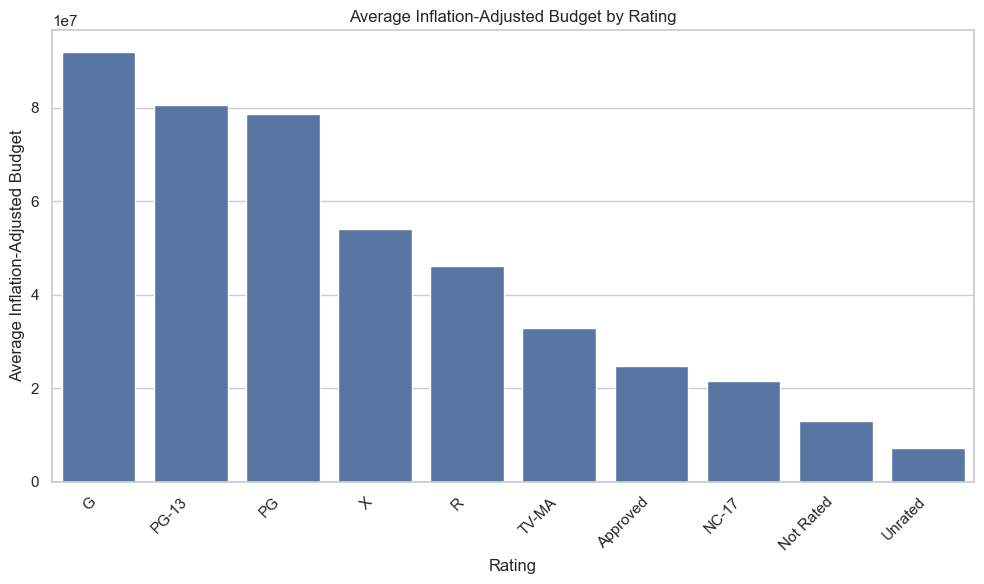

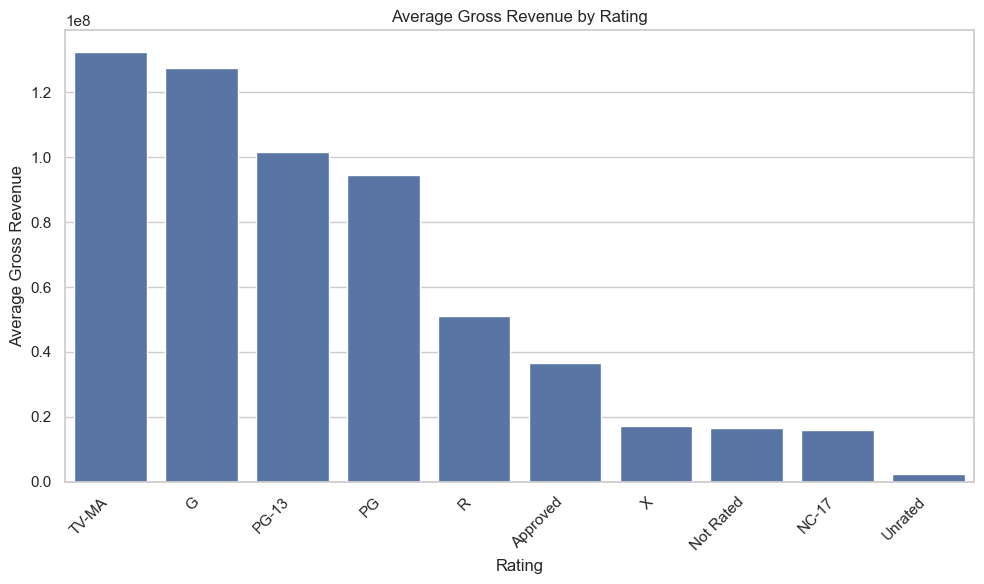

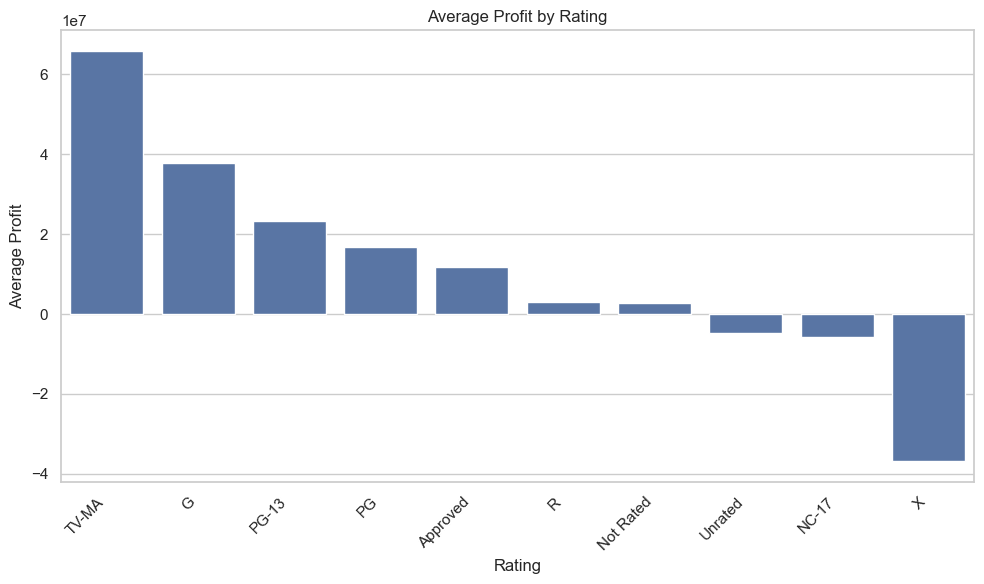

In [124]:
# Q6: Which ratings are more expensive to make?
bar_chart_mean(
    x_col='rating',
    y_col='budget_inflation_adjusted',
    title='Average Inflation-Adjusted Budget by Rating',
    xlabel='Rating',
    ylabel='Average Inflation-Adjusted Budget'
)

# Q7: Which ratings tend to produce higher gross revenues?
bar_chart_mean(
    x_col='rating',
    y_col='gross',
    title='Average Gross Revenue by Rating',
    xlabel='Rating',
    ylabel='Average Gross Revenue'
)

# Q8: Which ratings tend to generate more profit?
bar_chart_mean(
    x_col='rating',
    y_col='profit',
    title='Average Profit by Rating',
    xlabel='Rating',
    ylabel='Average Profit'
)


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_60976\3224270142.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_desc.groupby(x_col)[y_col]


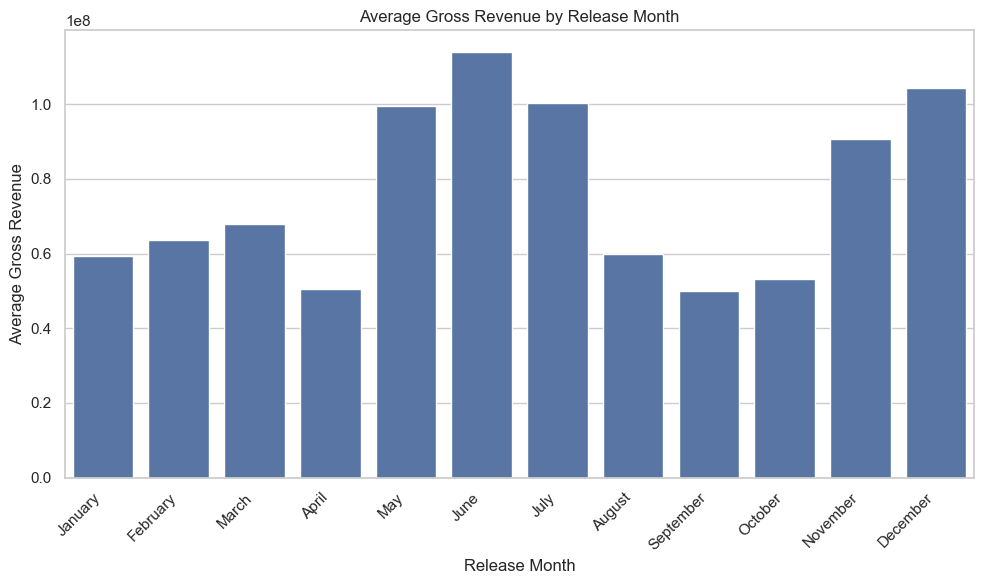

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_60976\3224270142.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_desc.groupby(x_col)[y_col]


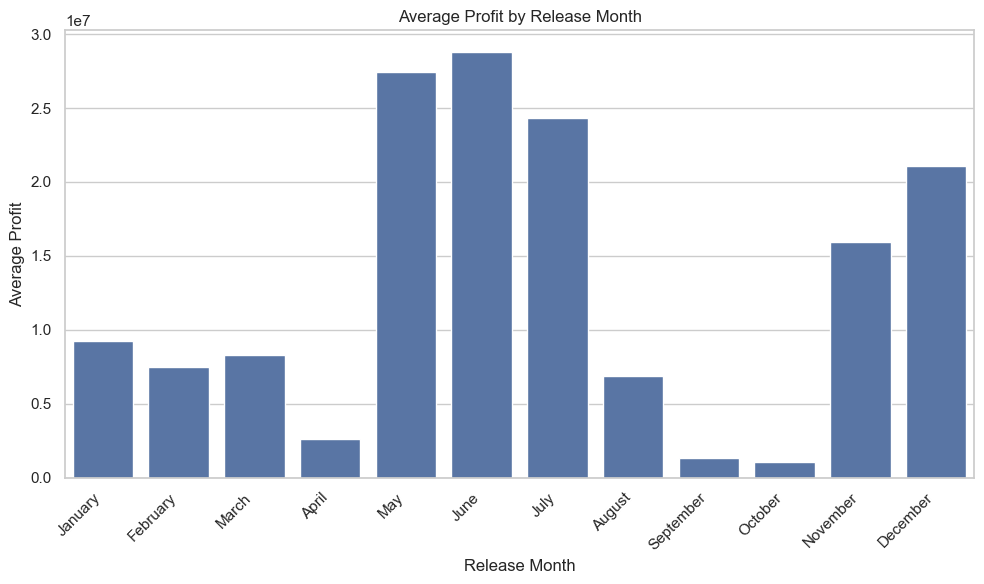

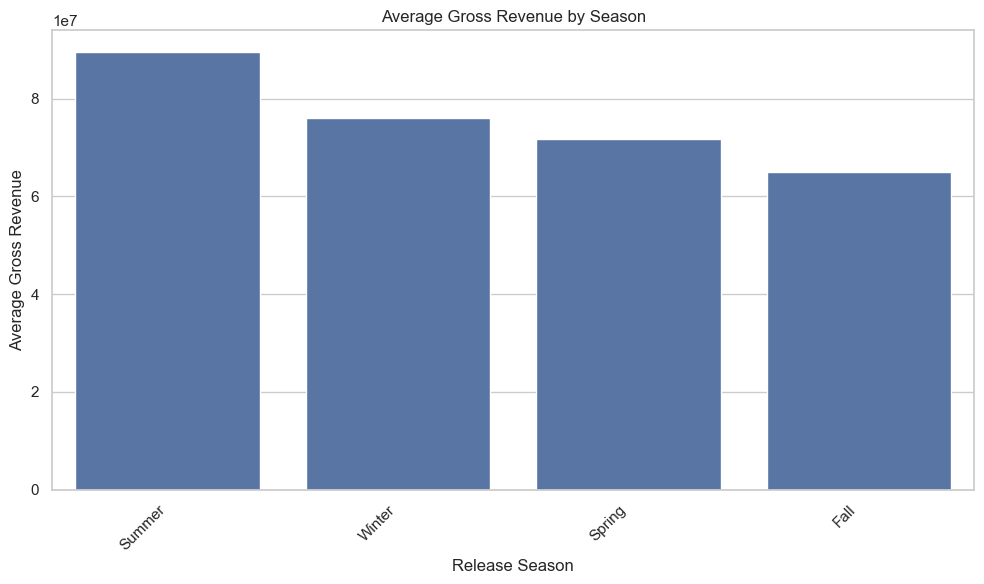

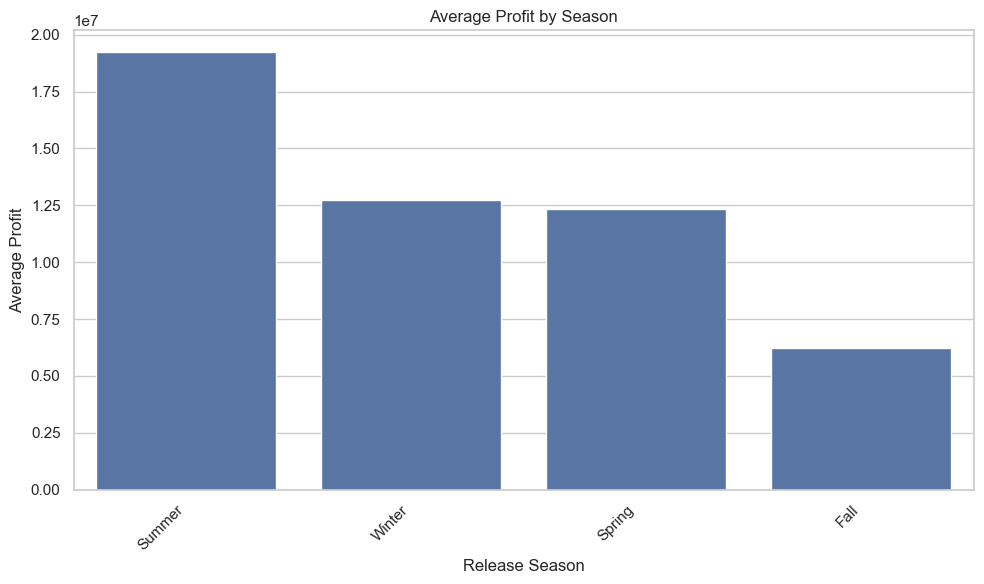

In [126]:
# To keep months ordered properly, define a category type
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
df_desc['release_month'] = pd.Categorical(df_desc['release_month'], categories=month_order, ordered=True)

# Q9: Releasing movies in which month led to higher gross revenues?
bar_chart_mean(
    x_col='release_month',
    y_col='gross',
    title='Average Gross Revenue by Release Month',
    xlabel='Release Month',
    ylabel='Average Gross Revenue'
)

# Q10: Releasing movies in which month led to higher profit?
bar_chart_mean(
    x_col='release_month',
    y_col='profit',
    title='Average Profit by Release Month',
    xlabel='Release Month',
    ylabel='Average Profit'
)

# Q11: Releasing movies in which season led to higher gross revenues?
bar_chart_mean(
    x_col='release_season',
    y_col='gross',
    title='Average Gross Revenue by Season',
    xlabel='Release Season',
    ylabel='Average Gross Revenue'
)

# Q12: Releasing movies in which season led to higher profit?
bar_chart_mean(
    x_col='release_season',
    y_col='profit',
    title='Average Profit by Season',
    xlabel='Release Season',
    ylabel='Average Profit'
)


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_60976\3224270142.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_desc.groupby(x_col)[y_col]


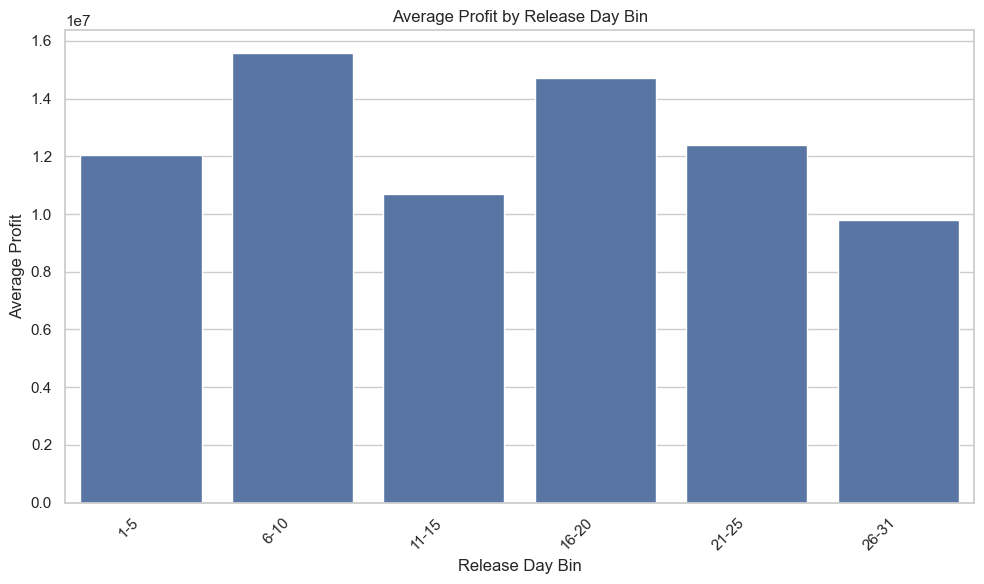

In [128]:
# Make sure bins are ordered
day_bin_order = ['1-5', '6-10', '11-15', '16-20', '21-25', '26-31']
df_desc['release_day_bin'] = pd.Categorical(df_desc['release_day_bin'], categories=day_bin_order, ordered=True)

# Q13: Which day bins led to the highest profit levels?
bar_chart_mean(
    x_col='release_day_bin',
    y_col='profit',
    title='Average Profit by Release Day Bin',
    xlabel='Release Day Bin',
    ylabel='Average Profit'
)

# Q14: Which day bins led to the lowest profit levels?
# (same chart as Q13 – you’ll interpret highest vs lowest in the report)


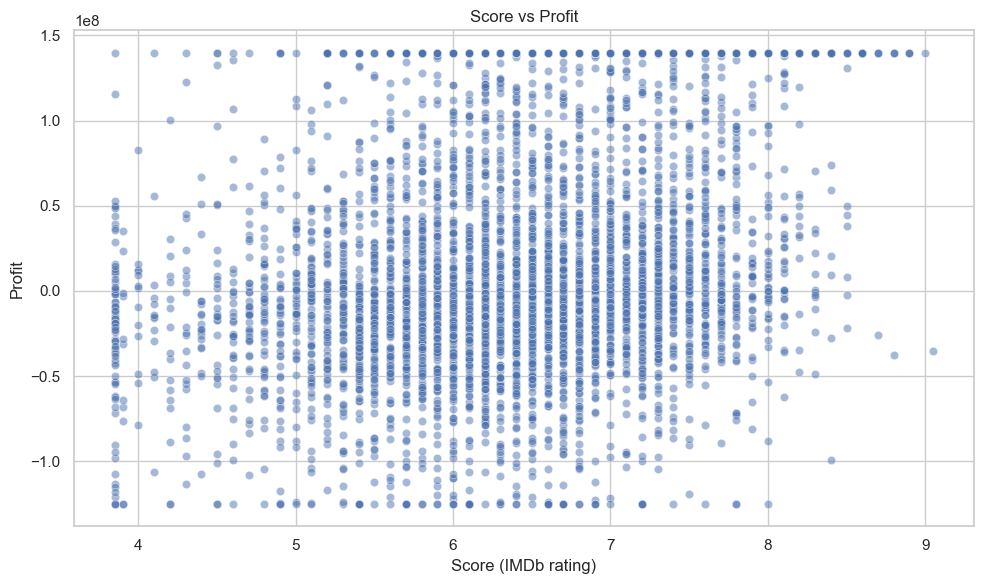

Correlation between score and profit: r = 0.28


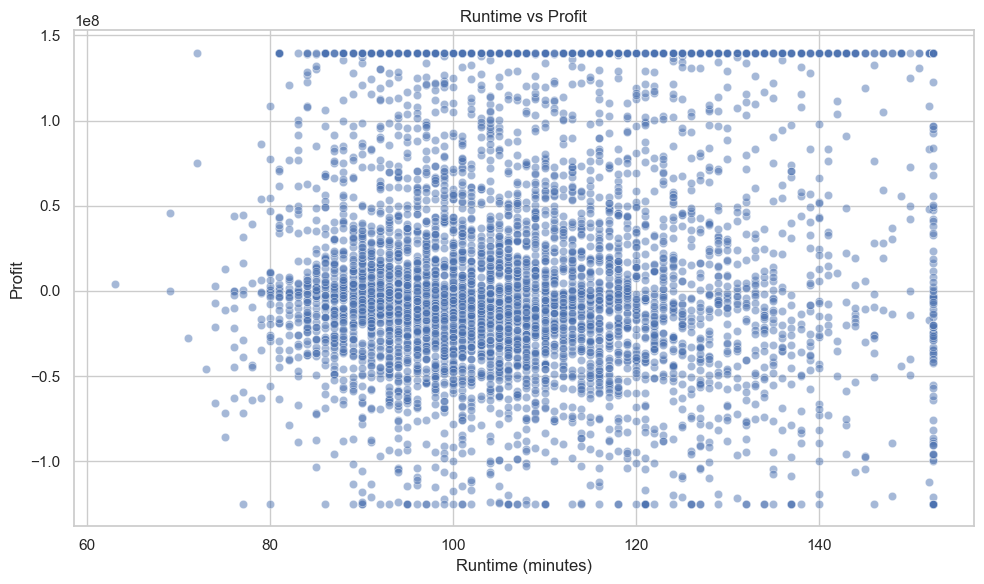

Correlation between runtime and profit: r = 0.11


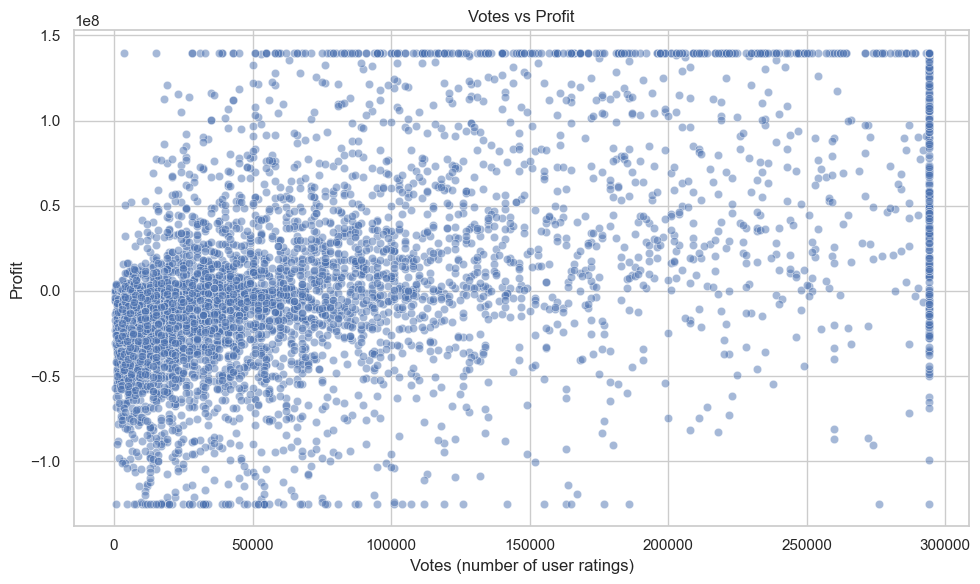

Correlation between votes and profit: r = 0.63


In [130]:
# Helper function: scatter + correlation
from scipy.stats import pearsonr

def scatter_and_corr(x_col, y_col, title, xlabel, ylabel):
    plt.figure()
    sns.scatterplot(data=df_desc, x=x_col, y=y_col, alpha=0.5)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()
    
    # Pearson correlation
    r = df_desc[[x_col, y_col]].corr().iloc[0,1]
    print(f"Correlation between {x_col} and {y_col}: r = {r:.2f}")

# Q15: Relationship between score and profit
scatter_and_corr(
    x_col='score',
    y_col='profit',
    title='Score vs Profit',
    xlabel='Score (IMDb rating)',
    ylabel='Profit'
)

# Q16: Relationship between runtime and profit
scatter_and_corr(
    x_col='runtime',
    y_col='profit',
    title='Runtime vs Profit',
    xlabel='Runtime (minutes)',
    ylabel='Profit'
)

# Q17: Relationship between votes and profit
scatter_and_corr(
    x_col='votes',
    y_col='profit',
    title='Votes vs Profit',
    xlabel='Votes (number of user ratings)',
    ylabel='Profit'
)


In [140]:
# ----------------------------- PART C: Hypothesis Testing -----------------------------
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Start from df_desc (cleaned dataset from Part B)
df_reg = df_desc.copy()

# 1. Make sure engineered variables exist
current_year = 2025
if 'years_since_production' not in df_reg.columns:
    df_reg['years_since_production'] = current_year - df_reg['release_year']

if 'movie_name_length' not in df_reg.columns:
    df_reg['movie_name_length'] = df_reg['name'].astype(str).str.len()

# 2. Select columns for H1–H9
reg_cols = [
    'profit',                 # dependent
    'score',                  # H1
    'votes',                  # H2
    'years_since_production', # H3
    'movie_name_length',      # H7
    'runtime',                # H8
    'rating',                 # H4
    'genre',                  # H5
    'release_month',          # H6
    'release_day_bin'         # H9
]

df_reg = df_reg[reg_cols].dropna().copy()

# 3. Dummy-code categorical variables (rating, genre, month, day bin)
df_reg = pd.get_dummies(
    df_reg,
    columns=['rating', 'genre', 'release_month', 'release_day_bin'],
    drop_first=False,
    dtype=float  # ensure numeric dtypes
)

# 4. Drop required reference categories
drop_list = [
    'rating_Unrated',          # rating baseline
    'genre_Biography',         # genre baseline
    'release_day_bin_26-31'    # day-bin baseline
]

for col in drop_list:
    if col in df_reg.columns:
        df_reg.drop(columns=[col], inplace=True)

# 5. Define Y and X
Y = df_reg['profit']
X = df_reg.drop(columns=['profit'])

# Keep only numeric predictors
X = X.select_dtypes(include=[np.number])

# Add intercept
X = sm.add_constant(X)

# 6. VIF (Multicollinearity Check)
vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print("\n--- VIF (Top 10 Highest) ---")
print(vif_data.sort_values(by='VIF', ascending=False).head(10))

# 7. Model 1: Unstandardized Regression
model_unstd = sm.OLS(Y, X).fit()
print("\n--- Model 1: Unstandardized Regression Results ---")
print(model_unstd.summary())

# 8. Model 2: Standardized Regression (all inputs standardized)
scaler = StandardScaler()

X_noconst = X.drop(columns=['const'])
X_scaled = scaler.fit_transform(X_noconst)

# IMPORTANT: keep the same index to avoid misalignment error
X_scaled_df = pd.DataFrame(X_scaled, columns=X_noconst.columns, index=X_noconst.index)
X_scaled_final = sm.add_constant(X_scaled_df)

model_std = sm.OLS(Y, X_scaled_final).fit()
print("\n--- Model 2: Standardized Regression Results ---")
print(model_std.summary())

# 9. Combined regression table for report
results_table = pd.DataFrame({
    'Independent_Variable': X.columns,
    'Unstandardized_Beta': model_unstd.params,
    'Standardized_Beta': model_std.params,
    'p_value': model_unstd.pvalues
})

# Format values
results_table['Unstandardized_Beta'] = results_table['Unstandardized_Beta'].round(2)
results_table['Standardized_Beta'] = results_table['Standardized_Beta'].round(2)

def format_p(p):
    if p < 0.001:
        return "<.001"
    else:
        return round(p, 3)

results_table['p_value'] = results_table['p_value'].apply(format_p)

# Separate constant row for table
const_row = results_table[results_table['Independent_Variable'] == 'const']
results_no_const = results_table[results_table['Independent_Variable'] != 'const']

print("\n--- CONSTANT ROW (for the table) ---")
print(const_row)

print("\n--- FINAL COMBINED REGRESSION TABLE (NO CONSTANT) ---")
print(results_no_const.head(20))


C:\Users\Lenovo\anaconda3\envs\py313\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
C:\Users\Lenovo\anaconda3\envs\py313\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)



--- VIF (Top 10 Highest) ---
                    feature  VIF
40   release_month_December  inf
33        release_month_May  inf
30   release_month_February  inf
31      release_month_March  inf
32      release_month_April  inf
37  release_month_September  inf
38    release_month_October  inf
39   release_month_November  inf
36     release_month_August  inf
29    release_month_January  inf

--- Model 1: Unstandardized Regression Results ---
                            OLS Regression Results                            
Dep. Variable:                 profit   R-squared:                       0.464
Model:                            OLS   Adj. R-squared:                  0.460
Method:                 Least Squares   F-statistic:                     106.0
Date:                Wed, 10 Dec 2025   Prob (F-statistic):               0.00
Time:                        22:47:59   Log-Likelihood:            -1.0344e+05
No. Observations:                5423   AIC:                         2.070e+05
Df

In [143]:
# ================================
# PART D – PREDICTIVE MODELING
# ================================

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import pandas as pd

# 1. Prepare data for ML
# ----------------------
# We will predict 'profit' using other variables.
# IMPORTANT: Do NOT use 'budget' or 'gross' as predictors.

df_ml = df.copy()

# (Optional but helpful) Dummy-code a few extra categorical vars for ML
# We already dummy-coded: rating, genre, company, release_season, release_day_bin
# Here we also dummy-code release_month and country for richer models.
cat_for_ml = []
if 'release_month' in df_ml.columns and df_ml['release_month'].dtype == 'O':
    cat_for_ml.append('release_month')
if 'country' in df_ml.columns and df_ml['country'].dtype == 'O':
    cat_for_ml.append('country')

if cat_for_ml:
    df_ml = pd.get_dummies(df_ml, columns=cat_for_ml, drop_first=True)

# Define target and feature columns
target_col = 'profit'

cols_to_exclude = [
    target_col,
    'gross',
    'budget',
    'name',
    'released',
    'director',
    'writer',
    'star',
    'release_date_clean'
]

feature_cols = [c for c in df_ml.columns if c not in cols_to_exclude]

# Keep only numeric features
X = df_ml[feature_cols].select_dtypes(include=[np.number])
y = df_ml[target_col]

print("Number of features used for ML:", X.shape[1])

# 2. Train-test split (70%-30%)
# ------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42
)

# 3. Decision Tree Regressor with basic hyperparameter tuning
# ------------------------------------------------------------
dt = DecisionTreeRegressor(random_state=42)

dt_param_grid = {
    'max_depth': [3, 5, 7, 9, None],
    'min_samples_split': [2, 10, 50],
    'min_samples_leaf': [1, 5, 10]
}

dt_grid = GridSearchCV(
    dt,
    param_grid=dt_param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

best_dt = dt_grid.best_estimator_
print("\nBest Decision Tree Params:", dt_grid.best_params_)

# Evaluate on test set
y_pred_dt = best_dt.predict(X_test)
dt_r2 = r2_score(y_test, y_pred_dt)
dt_rmse = np.sqrt(mean_squared_error(y_test, y_pred_dt))

print(f"Decision Tree - Test R²: {dt_r2:.3f}")
print(f"Decision Tree - Test RMSE: {dt_rmse:,.2f}")

# 4. Neural Network (MLPRegressor) with hyperparameter tuning
# ------------------------------------------------------------
mlp = MLPRegressor(random_state=42, max_iter=1000)

mlp_param_grid = {
    'hidden_layer_sizes': [(32,), (64,), (32, 16)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001, 0.01]
}

mlp_grid = GridSearchCV(
    mlp,
    param_grid=mlp_param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

mlp_grid.fit(X_train, y_train)

best_mlp = mlp_grid.best_estimator_
print("\nBest MLP Params:", mlp_grid.best_params_)

# Evaluate on test set
y_pred_mlp = best_mlp.predict(X_test)
mlp_r2 = r2_score(y_test, y_pred_mlp)
mlp_rmse = np.sqrt(mean_squared_error(y_test, y_pred_mlp))

print(f"Neural Network - Test R²: {mlp_r2:.3f}")
print(f"Neural Network - Test RMSE: {mlp_rmse:,.2f}")

# 5. Choose best model (higher R² on test set)
# --------------------------------------------
if mlp_r2 >= dt_r2:
    best_model = best_mlp
    best_model_name = "Neural Network (MLPRegressor)"
else:
    best_model = best_dt
    best_model_name = "Decision Tree Regressor"

print(f"\nBest overall model based on test R²: {best_model_name}")

# 6. Build the 3 new movies dataframe
# -----------------------------------
new_movies = pd.DataFrame([
    {
        'name': 'Gorga',
        'rating': 'R',
        'genre': 'Drama',
        'year': 2025,
        'released': 'June 1, 2026',
        'director': 'Alex Bandit',
        'writer': 'Frida Nour',
        'star': 'Marcello Mastroianni',
        'country': 'United States',
        'budget': 130000000,
        'company': 'Universal Pictures',
        'runtime': 250
    },
    {
        'name': 'King Wolf',
        'rating': 'R',
        'genre': 'Drama',
        'year': 2025,
        'released': 'March 1, 2027',
        'director': 'Alex Bandit',
        'writer': 'Dilip Sherman',
        'star': 'Paul Michael Glaser',
        'country': 'United States',
        'budget': 250000000,
        'company': 'Universal Pictures',
        'runtime': 135
    },
    {
        'name': 'Hellish Gray',
        'rating': 'PG',
        'genre': 'Comedy',
        'year': 2025,
        'released': 'July 1, 2026',
        'director': 'Alex Bandit',
        'writer': 'Franco Toro',
        'star': 'David N. Haynes',
        'country': 'United States',
        'budget': 310000000,
        'company': 'Universal Pictures',
        'runtime': 108
    }
])

# 6.1 – Recreate the same feature engineering pipeline used on df
# Clean 'released' and convert to date
new_movies['release_date_clean'] = new_movies['released'].astype(str).str.split(r' \(').str[0]

# If your fix_missing_day function is defined above, reuse it.
# If not, define quickly:
def fix_missing_day(date_str):
    parts = date_str.split()
    if len(parts) == 2 and parts[0].isalpha() and parts[1].isdigit() and len(parts[1]) == 4:
        return f"{parts[0]} 1, {parts[1]}"
    if len(parts) == 1 and parts[0].isdigit() and len(parts[0]) == 4:
        return f"January 1, {parts[0]}"
    return date_str

new_movies['release_date_clean'] = new_movies['release_date_clean'].apply(fix_missing_day)
new_movies['release_date_clean'] = pd.to_datetime(new_movies['release_date_clean'], errors='coerce')

# Date parts
new_movies['release_year'] = new_movies['release_date_clean'].dt.year
new_movies['release_month'] = new_movies['release_date_clean'].dt.month_name()
new_movies['release_day'] = new_movies['release_date_clean'].dt.day

# Season
def get_season(month):
    if month in ['March', 'April', 'May']:
        return 'Spring'
    elif month in ['June', 'July', 'August']:
        return 'Summer'
    elif month in ['September', 'October', 'November']:
        return 'Fall'
    else:
        return 'Winter'

new_movies['release_season'] = new_movies['release_month'].apply(get_season)

# Day bin
bins = [0, 5, 10, 15, 20, 25, 31]
labels = ['1-5', '6-10', '11-15', '16-20', '21-25', '26-31']
new_movies['release_day_bin'] = pd.cut(new_movies['release_day'], bins=bins, labels=labels, include_lowest=True)

# Inflation-adjusted budget (same formula as before)
current_year = 2025
inflation_rate = 0.0309
new_movies['budget_inflation_adjusted'] = new_movies['budget'] * ((1 + inflation_rate) ** (current_year - new_movies['year']))

# Movie name length
new_movies['movie_name_length'] = new_movies['name'].astype(str).str.len()

# Years since production – for future movies we set 0 years passed
new_movies['years_since_production'] = 0

# 6.2 – Fill missing score and votes with dataset means (as instructed)
mean_score = df['score'].mean()
mean_votes = df['votes'].mean()

new_movies['score'] = mean_score
new_movies['votes'] = mean_votes

# 6.3 – Apply same dummies as training data
# First, ensure same categorical structure as df_ml had before dummies
new_movies_ml = new_movies.copy()

# Dummy the same columns we used in df_ml
dummies_to_apply = []
for col in ['rating', 'genre', 'company', 'release_season', 'release_day_bin']:
    if col in new_movies_ml.columns:
        dummies_to_apply.append(col)
for col in ['release_month', 'country']:
    if col in new_movies_ml.columns:
        dummies_to_apply.append(col)

new_movies_ml = pd.get_dummies(new_movies_ml, columns=dummies_to_apply, drop_first=True)

# Keep only numeric columns and align columns with X_train
new_movies_ml = new_movies_ml.reindex(columns=X_train.columns, fill_value=0)

# 7. Predict profit for the three new movies using the best model
# ---------------------------------------------------------------
new_movies['predicted_profit'] = best_model.predict(new_movies_ml)

print("\nPredicted profit for the three new movies (using best model):")
print(new_movies[['name', 'rating', 'genre', 'budget', 'runtime', 'predicted_profit']])


Number of features used for ML: 9

Best Decision Tree Params: {'max_depth': 7, 'min_samples_leaf': 10, 'min_samples_split': 50}
Decision Tree - Test R²: 0.522
Decision Tree - Test RMSE: 43,401,156.83

Best MLP Params: {'activation': 'relu', 'alpha': 0.01, 'hidden_layer_sizes': (32, 16)}
Neural Network - Test R²: 0.463
Neural Network - Test RMSE: 45,980,049.09

Best overall model based on test R²: Decision Tree Regressor

Predicted profit for the three new movies (using best model):
           name rating   genre     budget  runtime  predicted_profit
0         Gorga      R   Drama  130000000      250     69,065,897.70
1     King Wolf      R   Drama  250000000      135     69,065,897.70
2  Hellish Gray     PG  Comedy  310000000      108     69,065,897.70
